In [1]:

import pandas as pd
import numpy as np
from sklearn.datasets import load_iris

iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['species'] = iris.target
df['species_name'] = df['species'].map({0: 'setosa', 1: 'versicolor', 2: 'virginica'})

print(df.head())
print(f"\nShape: {df.shape}")

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   species species_name  
0        0       setosa  
1        0       setosa  
2        0       setosa  
3        0       setosa  
4        0       setosa  

Shape: (150, 6)


In [2]:

def check_data_quality(dataframe):

    print("Missing values:\n", dataframe.isnull().sum())
    print("\nDuplicates:", dataframe.duplicated().sum())
    print("\nData types:\n", dataframe.dtypes)
    print("\nClass balance:\n", dataframe['species_name'].value_counts())

check_data_quality(df)

Missing values:
 sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
species              0
species_name         0
dtype: int64

Duplicates: 1

Data types:
 sepal length (cm)    float64
sepal width (cm)     float64
petal length (cm)    float64
petal width (cm)     float64
species                int64
species_name          object
dtype: object

Class balance:
 species_name
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


In [3]:

duplicate_rows = df[df.duplicated(keep=False)]
print(duplicate_rows)

     sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
101                5.8               2.7                5.1               1.9   
142                5.8               2.7                5.1               1.9   

     species species_name  
101        2    virginica  
142        2    virginica  


In [4]:
# %% Cell 2c: Handle Duplicate Decision
# NOTE: Found 1 duplicate row (index 101 & 142, both 'virginica').
# Decision: KEEP the duplicate. Reasoning:
#   1. Small dataset (150 rows) - standard Iris dataset is preserved as-is
#      to match the canonical version used across research/benchmarks.
#   2. Both measurements are plausible (not a clear entry error).
#   3. This is a portfolio/learning project, not a production pipeline.
# Trade-off acknowledged: minor data leakage risk if these rows split
# across train/test - will monitor if results seem inflated.
print("Duplicate row decision: KEEP (documented above)")

Duplicate row decision: KEEP (documented above)


In [5]:
# %% Cell 3: Distribution Analysis
feature_columns = iris.feature_names

print("Overall statistics (features only):")
print(df[feature_columns].describe())

print("\n\nStatistics grouped by species:")
print(df.groupby('species_name')[feature_columns].describe())

Overall statistics (features only):
       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         150.000000        150.000000         150.000000   
mean            5.843333          3.057333           3.758000   
std             0.828066          0.435866           1.765298   
min             4.300000          2.000000           1.000000   
25%             5.100000          2.800000           1.600000   
50%             5.800000          3.000000           4.350000   
75%             6.400000          3.300000           5.100000   
max             7.900000          4.400000           6.900000   

       petal width (cm)  
count        150.000000  
mean           1.199333  
std            0.762238  
min            0.100000  
25%            0.300000  
50%            1.300000  
75%            1.800000  
max            2.500000  


Statistics grouped by species:
             sepal length (cm)                                              \
                         count   

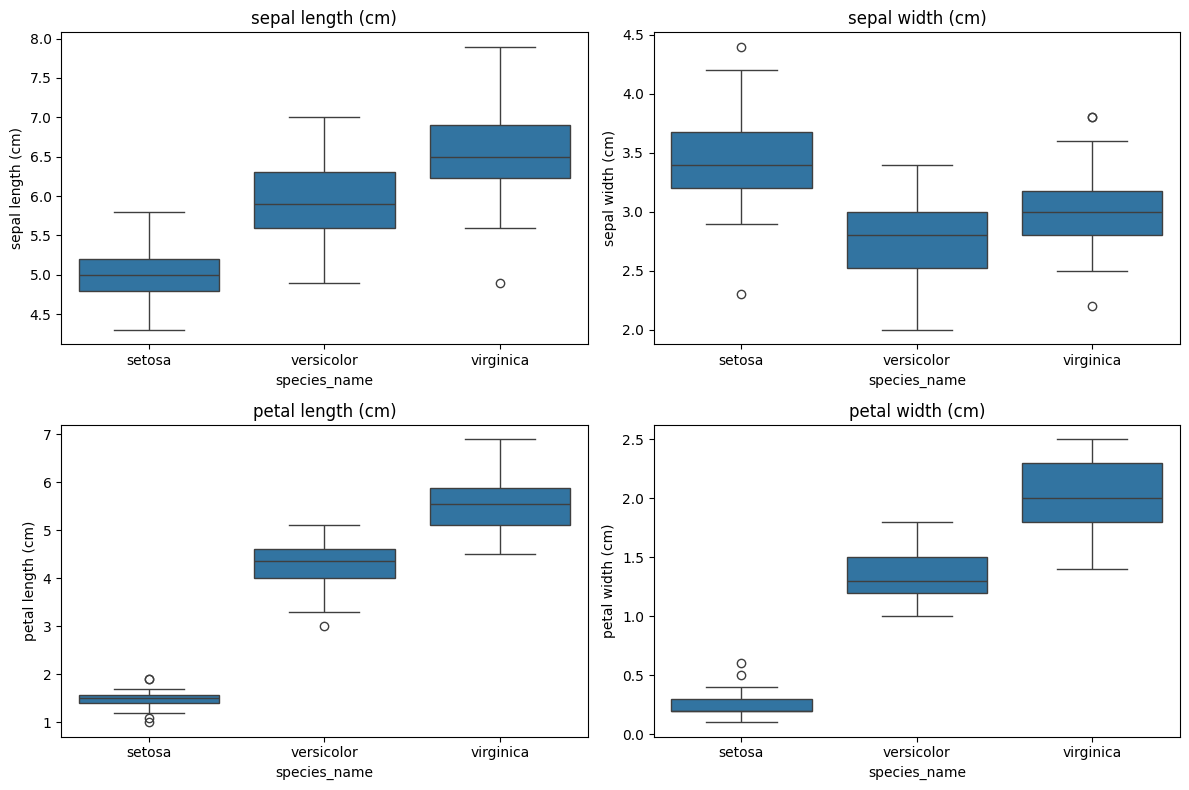

In [6]:
# Boxplot Visualization
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, feature in enumerate(feature_columns):
    sns.boxplot(data=df, x='species_name', y=feature, ax=axes[i])
    axes[i].set_title(feature)

plt.tight_layout()
plt.show()

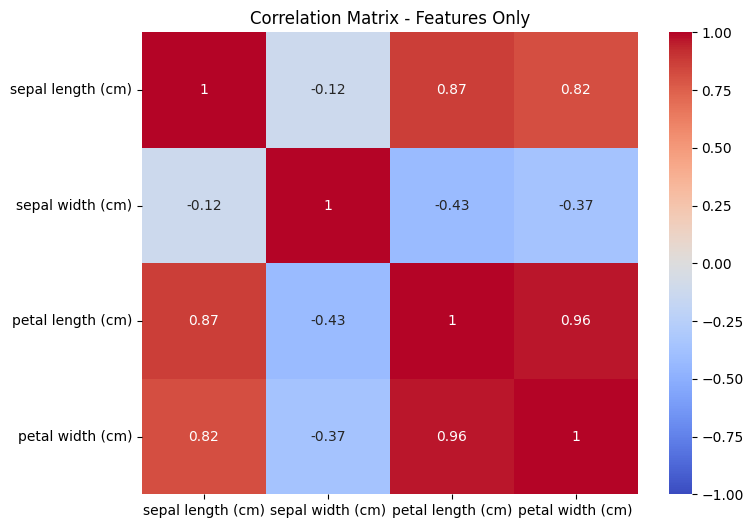

                   sepal length (cm)  sepal width (cm)  petal length (cm)  \
sepal length (cm)           1.000000         -0.117570           0.871754   
sepal width (cm)           -0.117570          1.000000          -0.428440   
petal length (cm)           0.871754         -0.428440           1.000000   
petal width (cm)            0.817941         -0.366126           0.962865   

                   petal width (cm)  
sepal length (cm)          0.817941  
sepal width (cm)          -0.366126  
petal length (cm)          0.962865  
petal width (cm)           1.000000  


In [7]:
# Cell 5: Correlation Analysis
correlation_matrix = df[feature_columns].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Matrix - Features Only')
plt.show()

print(correlation_matrix)

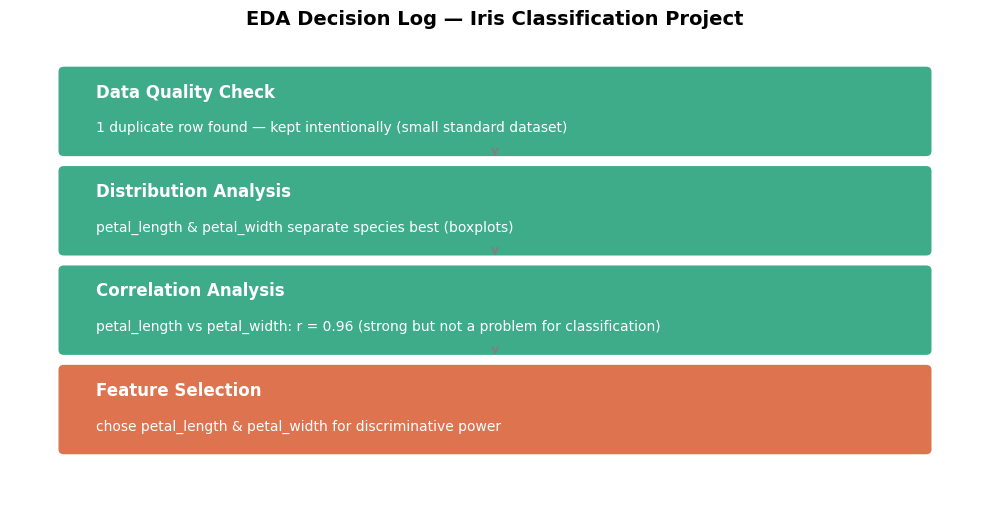

In [8]:
#Cell 6: EDA Decisions Summary (Documentation Chart)
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

def plot_decision_log(decisions):

    fig, ax = plt.subplots(figsize=(10, len(decisions) * 1.3))
    box_height = 0.8

    for i, (title, finding) in enumerate(decisions):
        y = len(decisions) - i - 1
        color = '#D85A30' if i == len(decisions) - 1 else '#1D9E75'
        rect = mpatches.FancyBboxPatch(
            (0, y), 8, box_height,
            boxstyle="round,pad=0.05",
            facecolor=color, edgecolor='none', alpha=0.85
        )
        ax.add_patch(rect)
        ax.text(0.3, y + box_height/2 + 0.15, title, fontsize=12, fontweight='bold', color='white')
        ax.text(0.3, y + box_height/2 - 0.2, finding, fontsize=10, color='white')

        if i < len(decisions) - 1:
            ax.annotate('', xy=(4, y - 0.05), xytext=(4, y),
                        arrowprops=dict(arrowstyle='->', color='gray', lw=1.5))

    ax.set_xlim(-0.5, 8.5)
    ax.set_ylim(-0.5, len(decisions))
    ax.axis('off')
    ax.set_title('EDA Decision Log — Iris Classification Project', fontsize=14, fontweight='bold', pad=20)
    plt.tight_layout()
    plt.show()


decisions_log = [
    ("Data Quality Check", "1 duplicate row found — kept intentionally (small standard dataset)"),
    ("Distribution Analysis", "petal_length & petal_width separate species best (boxplots)"),
    ("Correlation Analysis", "petal_length vs petal_width: r = 0.96 (strong but not a problem for classification)"),
    ("Feature Selection", "chose petal_length & petal_width for discriminative power"),
]

plot_decision_log(decisions_log)

In [9]:
#Cell 7: Train/Test Split
from sklearn.model_selection import train_test_split

X = df[feature_columns]
y = df['species']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print(f"Train size: {X_train.shape[0]}, Test size: {X_test.shape[0]}")
print("\nTrain class distribution:\n", y_train.value_counts(normalize=True))
print("\nTest class distribution:\n", y_test.value_counts(normalize=True))

Train size: 120, Test size: 30

Train class distribution:
 species
0    0.333333
2    0.333333
1    0.333333
Name: proportion, dtype: float64

Test class distribution:
 species
0    0.333333
2    0.333333
1    0.333333
Name: proportion, dtype: float64


In [11]:
#Cell 8: Cross-Validation
from sklearn.model_selection import cross_val_score
from sklearn.neighbors import KNeighborsClassifier

model = KNeighborsClassifier(n_neighbors=5)
cv_scores = cross_val_score(model, X, y, cv=5)  # 5-fold cross-validation

print("Accuracy per fold:", cv_scores)
print(f"\nMean accuracy: {cv_scores.mean():.2%}")
print(f"Standard deviation: {cv_scores.std():.2%}")

Accuracy per fold: [0.96666667 1.         0.93333333 0.96666667 1.        ]

Mean accuracy: 97.33%
Standard deviation: 2.49%


In [12]:
#Cell 9: Compare Multiple Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

models = {
    "Logistic Regression": LogisticRegression(max_iter=200),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "SVM": SVC(),
}

results = {}
for name, model in models.items():
    scores = cross_val_score(model, X, y, cv=5)
    results[name] = scores
    print(f"{name:20s} -> Mean: {scores.mean():.2%}, Std: {scores.std():.2%}")

Logistic Regression  -> Mean: 97.33%, Std: 2.49%
KNN                  -> Mean: 97.33%, Std: 2.49%
Decision Tree        -> Mean: 95.33%, Std: 3.40%
Random Forest        -> Mean: 96.67%, Std: 2.11%
SVM                  -> Mean: 96.67%, Std: 2.11%


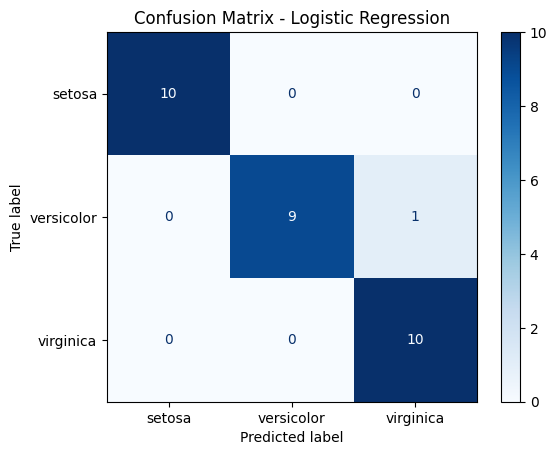

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



In [13]:
#Cell 10: Final Model Training & Evaluation
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay


final_model = LogisticRegression(max_iter=200)
final_model.fit(X_train, y_train)


y_pred = final_model.predict(X_test)


cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=iris.target_names)
disp.plot(cmap='Blues')
plt.title('Confusion Matrix - Logistic Regression')
plt.show()

# 2. Classification Report (precision, recall, f1-score )
print(classification_report(y_test, y_pred, target_names=iris.target_names))

In [14]:
#Cell 11: Save the Trained Model
import joblib


joblib.dump(final_model, 'iris_model.joblib')

print("done iris_model.joblib")

done iris_model.joblib
